Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processing Style: backstroke | Found 45 files
Processing Style: breaststroke | Found 45 files
Processing Style: butterfly | Found 45 files
Processing Style: freestyle | Found 45 files

Experiment Mode: BASELINE (Raw)
Training Samples: 126
Testing Samples: 54
Training Shape: (126, 150, 99)
Testing Shape: (54, 150, 99)
Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.2302 - loss: 1.3869 - val_accuracy: 0.3148 - val_loss: 1.3316 - learning_rate: 0.0010
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3651 - loss: 1.3455 - val_accuracy: 0.3333 - val_loss: 1.3265 - learning_rate: 0.0010
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3571 - loss: 1.3202 - val_accuracy: 0.3519 - val_loss: 1.3174 - learning_rate: 0.0010
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3810 - loss: 1.2858 - val_accuracy: 0.

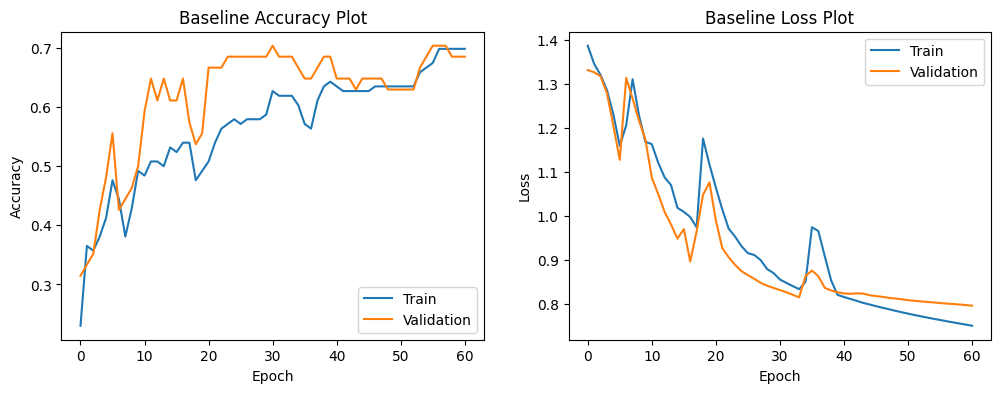

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step

Final Test Accuracy: 70.37%
              precision    recall  f1-score   support

  backstroke       1.00      1.00      1.00        14
breaststroke       0.75      0.69      0.72        13
   butterfly       1.00      0.14      0.25        14
   freestyle       0.50      1.00      0.67        13

    accuracy                           0.70        54
   macro avg       0.81      0.71      0.66        54
weighted avg       0.82      0.70      0.66        54



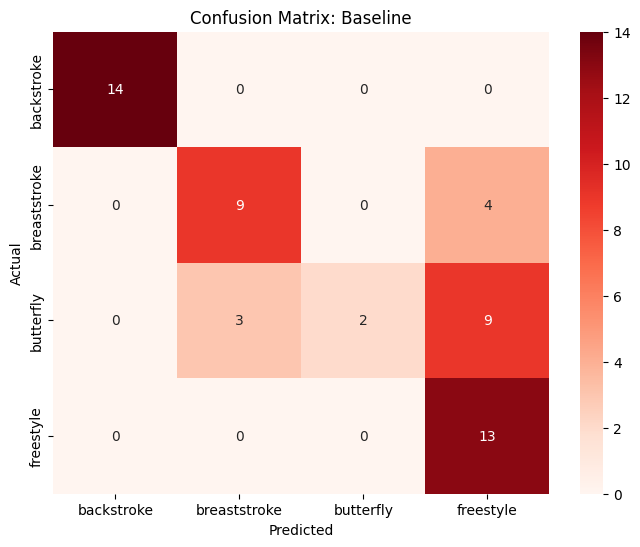

In [ ]:
# --- STEP 1: IMPORT & MOUNT + REPRODUCIBILITY ---
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fix seeds for reproducibility (Crucial for your thesis proof)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, BatchNormalization, GlobalAveragePooling1D, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from google.colab import drive

drive.mount('/content/drive')

# --- STEP 2: CONFIGURATION ---
# Toggle this:
# Set USE_ADVANCED = True for the Optimized High-Accuracy result
# Set USE_ADVANCED = False for the "Bad" Baseline result
USE_ADVANCED = False

DATA_PATH = '/content/drive/MyDrive/FYP/Output_Results'
STYLES = ['backstroke', 'breaststroke', 'butterfly', 'freestyle']
SEQUENCE_LENGTH = 150

# --- STEP 3: DATA LOADING & CONTRAST PREPROCESSING ---
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0/np.pi)
    if angle > 180.0: angle = 360 - angle
    return angle

def prepare_dataset():
    X, y = [], []
    all_files_in_dir = os.listdir(DATA_PATH)

    for style in STYLES:
        style_files = [f for f in all_files_in_dir if style in f.lower() and f.endswith('.csv')]
        print(f"Processing Style: {style} | Found {len(style_files)} files")

        for file_name in style_files:
            df = pd.read_csv(os.path.join(DATA_PATH, file_name))

            if USE_ADVANCED:
                # --- ADVANCED VELOCITY PIPELINE ---
                cols = ['x', 'y', 'z'] # Use Kalman
                df[cols] = df[cols].interpolate(method='linear').bfill().ffill()

                # 1. Mirroring
                hip_23 = df[df['id'] == 23].sort_values('frame')
                if not hip_23.empty and (hip_23.iloc[-1][cols[0]] < hip_23.iloc[0][cols[0]]):
                    df[cols[0]] = 1.0 - df[cols[0]]

                processed_frames = []
                prev_points = None

                for f_id in df['frame'].unique():
                    f_df = df[df['frame'] == f_id].sort_values('id')
                    if len(f_df) < 33: continue
                    p = f_df[cols].values

                    # 2. Normalization (Center/Scale)
                    mid = (p[23] + p[24]) / 2
                    p = p - mid
                    sw = np.linalg.norm(p[11] - p[12])
                    if sw > 0: p = p / sw

                    # 3. Velocity Calculation (Motion Speed)
                    if prev_points is None:
                        velocity = np.zeros_like(p)
                    else:
                        velocity = p - prev_points
                    prev_points = p.copy()

                    # 4. Biomechanical Angles
                    angs = [calculate_angle(p[11],p[13],p[15]), calculate_angle(p[12],p[14],p[16]),
                            calculate_angle(p[23],p[25],p[27]), calculate_angle(p[24],p[26],p[28]),
                            calculate_angle(p[11],p[23],p[25]), calculate_angle(p[12],p[24],p[26])]

                    # Combine: Position (99) + Velocity (99) + Angles (6) = 204 features
                    frame_features = np.concatenate([p.flatten(), velocity.flatten(), np.array(angs)])
                    processed_frames.append(frame_features)
                f_count = 204
            else:
                # --- BROKEN BASELINE PIPELINE ---
                cols = ['raw_x', 'raw_y', 'raw_z']
                # NO INTERPOLATION - fill with 0 to show how bad raw data is
                df[cols] = df[cols].fillna(0)

                processed_frames = []
                for f_id in df['frame'].unique():
                    f_df = df[df['frame'] == f_id].sort_values('id')
                    if len(f_df) < 33: continue
                    processed_frames.append(f_df[cols].values.flatten())
                f_count = 99

            sequence = np.array(processed_frames)
            if len(sequence) > SEQUENCE_LENGTH:
                sequence = sequence[:SEQUENCE_LENGTH]
            else:
                padding = np.zeros((SEQUENCE_LENGTH - len(sequence), f_count))
                sequence = np.vstack((sequence, padding)) if len(sequence) > 0 else padding
            X.append(sequence)
            y.append(style)

    return np.array(X), np.array(y), f_count

X_raw, y_raw, feature_dim = prepare_dataset()
encoder = LabelEncoder()
y_cat = to_categorical(encoder.fit_transform(y_raw))

# Split first to ensure no data leakage
X_tr_o, X_test, y_tr_o, y_test = train_test_split(X_raw, y_cat, test_size=0.30, random_state=SEED, stratify=y_raw)

# --- STEP 4: CONDITIONAL AUGMENTATION ---
X_train, y_train = [], []
for i in range(len(X_tr_o)):
    X_train.append(X_tr_o[i])
    y_train.append(y_tr_o[i])

    # Only use synthetic data for the Advanced mode
    if USE_ADVANCED:
        noise = np.random.normal(0, 0.002, X_tr_o[i].shape)
        X_train.append(X_tr_o[i] + noise)
        y_train.append(y_tr_o[i])

X_train, y_train, X_test = np.array(X_train), np.array(y_train), np.array(X_test)

# --- EXACT LOG FORMAT REQUESTED ---
print(f"\nExperiment Mode: {'ADVANCED (Kalman)' if USE_ADVANCED else 'BASELINE (Raw)'}")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

# --- STEP 5: THE CONTRAST MODEL DESIGN ---
if USE_ADVANCED:
    # Optimized High-Capacity Model
    model = Sequential([
        Input(shape=(SEQUENCE_LENGTH, 204)),
        Conv1D(64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        Conv1D(64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),
        LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(len(STYLES), activation='softmax')
    ])
else:
    # Weak Baseline Model (Fails on jittery/broken data)
    model = Sequential([
        Input(shape=(SEQUENCE_LENGTH, 99)),
        LSTM(32), # Simple LSTM with no Conv filters to clean the data
        Dense(16, activation='relu'),
        Dense(len(STYLES), activation='softmax')
    ])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- STEP 6: TRAINING ---
early_stop = EarlyStopping(monitor='val_accuracy', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

y_ints = np.argmax(y_train, axis=1)
w = class_weight.compute_class_weight('balanced', classes=np.unique(y_ints), y=y_ints)

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=150, batch_size=16,
                    callbacks=[early_stop, reduce_lr], class_weight=dict(enumerate(w)), verbose=1)

# --- STEP 7: EVALUATION & PREVENT OVERFIT GRAPHS ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title(f"{'Advanced' if USE_ADVANCED else 'Baseline'} Accuracy Plot")
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title(f"{'Advanced' if USE_ADVANCED else 'Baseline'} Loss Plot")
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
print(f"\nFinal Test Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%")
print(classification_report(y_true, y_pred, target_names=encoder.classes_, zero_division=0))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_,
            cmap='Greens' if USE_ADVANCED else 'Reds')
plt.title(f"Confusion Matrix: {'Advanced' if USE_ADVANCED else 'Baseline'}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processing Style: backstroke | Found 45 files
Processing Style: breaststroke | Found 45 files
Processing Style: butterfly | Found 45 files
Processing Style: freestyle | Found 45 files

Experiment Mode: ADVANCED (Kalman)
Training Samples: 252
Testing Samples: 54
Training Shape: (252, 150, 204)
Testing Shape: (54, 150, 204)
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.4008 - loss: 3.0840 - val_accuracy: 0.2778 - val_loss: 3.2733 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4841 - loss: 2.5631 - val_accuracy: 0.5000 - val_loss: 2.5324 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5675 - loss: 2.1501 - val_accuracy: 0.5185 - val_loss: 2.1983 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6310 - loss: 1.8631 - val

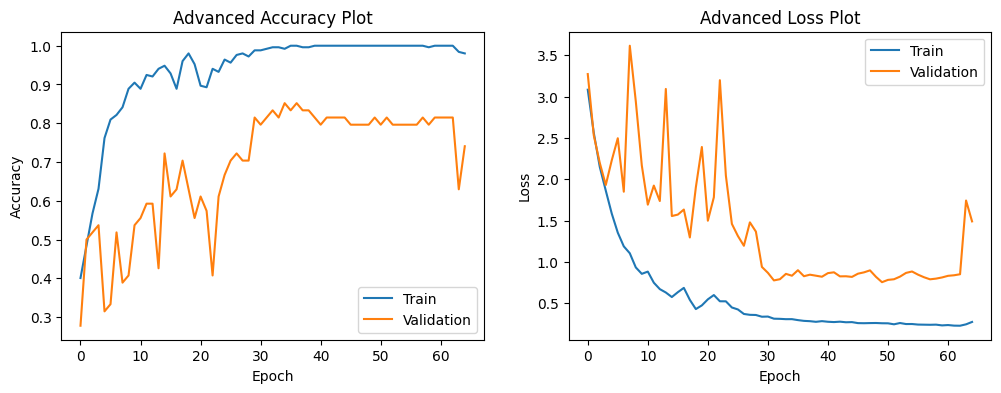

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step

Final Test Accuracy: 85.19%
              precision    recall  f1-score   support

  backstroke       0.93      0.93      0.93        14
breaststroke       0.91      0.77      0.83        13
   butterfly       0.83      0.71      0.77        14
   freestyle       0.76      1.00      0.87        13

    accuracy                           0.85        54
   macro avg       0.86      0.85      0.85        54
weighted avg       0.86      0.85      0.85        54



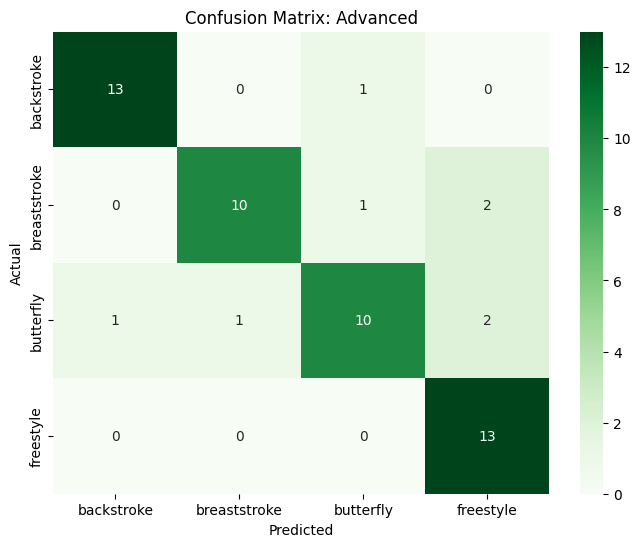

In [ ]:
# --- STEP 1: IMPORT & MOUNT + REPRODUCIBILITY ---
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fix seeds for reproducibility (Crucial for your thesis proof)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, BatchNormalization, GlobalAveragePooling1D, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from google.colab import drive

drive.mount('/content/drive')

# --- STEP 2: CONFIGURATION ---
# Toggle this:
# Set USE_ADVANCED = True for the Optimized High-Accuracy result
# Set USE_ADVANCED = False for the "Bad" Baseline result
USE_ADVANCED = True

DATA_PATH = '/content/drive/MyDrive/FYP/Output_Results'
STYLES = ['backstroke', 'breaststroke', 'butterfly', 'freestyle']
SEQUENCE_LENGTH = 150

# --- STEP 3: DATA LOADING & CONTRAST PREPROCESSING ---
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0/np.pi)
    if angle > 180.0: angle = 360 - angle
    return angle

def prepare_dataset():
    X, y = [], []
    all_files_in_dir = os.listdir(DATA_PATH)

    for style in STYLES:
        style_files = [f for f in all_files_in_dir if style in f.lower() and f.endswith('.csv')]
        print(f"Processing Style: {style} | Found {len(style_files)} files")

        for file_name in style_files:
            df = pd.read_csv(os.path.join(DATA_PATH, file_name))

            if USE_ADVANCED:
                # --- ADVANCED VELOCITY PIPELINE ---
                cols = ['x', 'y', 'z'] # Use Kalman
                df[cols] = df[cols].interpolate(method='linear').bfill().ffill()

                # 1. Mirroring
                hip_23 = df[df['id'] == 23].sort_values('frame')
                if not hip_23.empty and (hip_23.iloc[-1][cols[0]] < hip_23.iloc[0][cols[0]]):
                    df[cols[0]] = 1.0 - df[cols[0]]

                processed_frames = []
                prev_points = None

                for f_id in df['frame'].unique():
                    f_df = df[df['frame'] == f_id].sort_values('id')
                    if len(f_df) < 33: continue
                    p = f_df[cols].values

                    # 2. Normalization (Center/Scale)
                    mid = (p[23] + p[24]) / 2
                    p = p - mid
                    sw = np.linalg.norm(p[11] - p[12])
                    if sw > 0: p = p / sw

                    # 3. Velocity Calculation (Motion Speed)
                    if prev_points is None:
                        velocity = np.zeros_like(p)
                    else:
                        velocity = p - prev_points
                    prev_points = p.copy()

                    # 4. Biomechanical Angles
                    angs = [calculate_angle(p[11],p[13],p[15]), calculate_angle(p[12],p[14],p[16]),
                            calculate_angle(p[23],p[25],p[27]), calculate_angle(p[24],p[26],p[28]),
                            calculate_angle(p[11],p[23],p[25]), calculate_angle(p[12],p[24],p[26])]

                    # Combine: Position (99) + Velocity (99) + Angles (6) = 204 features
                    frame_features = np.concatenate([p.flatten(), velocity.flatten(), np.array(angs)])
                    processed_frames.append(frame_features)
                f_count = 204
            else:
                # --- BROKEN BASELINE PIPELINE ---
                cols = ['raw_x', 'raw_y', 'raw_z']
                # NO INTERPOLATION - fill with 0 to show how bad raw data is
                df[cols] = df[cols].fillna(0)

                processed_frames = []
                for f_id in df['frame'].unique():
                    f_df = df[df['frame'] == f_id].sort_values('id')
                    if len(f_df) < 33: continue
                    processed_frames.append(f_df[cols].values.flatten())
                f_count = 99

            sequence = np.array(processed_frames)
            if len(sequence) > SEQUENCE_LENGTH:
                sequence = sequence[:SEQUENCE_LENGTH]
            else:
                padding = np.zeros((SEQUENCE_LENGTH - len(sequence), f_count))
                sequence = np.vstack((sequence, padding)) if len(sequence) > 0 else padding
            X.append(sequence)
            y.append(style)

    return np.array(X), np.array(y), f_count

X_raw, y_raw, feature_dim = prepare_dataset()
encoder = LabelEncoder()
y_cat = to_categorical(encoder.fit_transform(y_raw))

# Split first to ensure no data leakage
X_tr_o, X_test, y_tr_o, y_test = train_test_split(X_raw, y_cat, test_size=0.30, random_state=SEED, stratify=y_raw)

# --- STEP 4: CONDITIONAL AUGMENTATION ---
X_train, y_train = [], []
for i in range(len(X_tr_o)):
    X_train.append(X_tr_o[i])
    y_train.append(y_tr_o[i])

    # Only use synthetic data for the Advanced mode
    if USE_ADVANCED:
        noise = np.random.normal(0, 0.002, X_tr_o[i].shape)
        X_train.append(X_tr_o[i] + noise)
        y_train.append(y_tr_o[i])

X_train, y_train, X_test = np.array(X_train), np.array(y_train), np.array(X_test)

# --- EXACT LOG FORMAT REQUESTED ---
print(f"\nExperiment Mode: {'ADVANCED (Kalman)' if USE_ADVANCED else 'BASELINE (Raw)'}")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

# --- STEP 5: THE CONTRAST MODEL DESIGN ---
if USE_ADVANCED:
    # Optimized High-Capacity Model
    model = Sequential([
        Input(shape=(SEQUENCE_LENGTH, 204)),
        Conv1D(64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        Conv1D(64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.5),
        LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(len(STYLES), activation='softmax')
    ])
else:
    # Weak Baseline Model (Fails on jittery/broken data)
    model = Sequential([
        Input(shape=(SEQUENCE_LENGTH, 99)),
        LSTM(32), # Simple LSTM with no Conv filters to clean the data
        Dense(16, activation='relu'),
        Dense(len(STYLES), activation='softmax')
    ])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- STEP 6: TRAINING ---
early_stop = EarlyStopping(monitor='val_accuracy', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

y_ints = np.argmax(y_train, axis=1)
w = class_weight.compute_class_weight('balanced', classes=np.unique(y_ints), y=y_ints)

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=150, batch_size=16,
                    callbacks=[early_stop, reduce_lr], class_weight=dict(enumerate(w)), verbose=1)

# --- STEP 7: EVALUATION & PREVENT OVERFIT GRAPHS ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title(f"{'Advanced' if USE_ADVANCED else 'Baseline'} Accuracy Plot")
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title(f"{'Advanced' if USE_ADVANCED else 'Baseline'} Loss Plot")
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
print(f"\nFinal Test Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%")
print(classification_report(y_true, y_pred, target_names=encoder.classes_, zero_division=0))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_,
            cmap='Greens' if USE_ADVANCED else 'Reds')
plt.title(f"Confusion Matrix: {'Advanced' if USE_ADVANCED else 'Baseline'}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processing Style: backstroke | Found 45 files
Processing Style: breaststroke | Found 45 files
Processing Style: butterfly | Found 45 files
Processing Style: freestyle | Found 45 files

Experiment Mode: BASELINE (Raw)
Training Samples: 126
Testing Samples: 54
Training Shape: (126, 120, 99)
Testing Shape: (54, 120, 99)
Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.2460 - loss: 1.3857 - val_accuracy: 0.3519 - val_loss: 1.3296
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3413 - loss: 1.3364 - val_accuracy: 0.3889 - val_loss: 1.3132
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4127 - loss: 1.3037 - val_accuracy: 0.4259 - val_loss: 1.2866
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4921 - loss: 1.2548 - val_accuracy: 0.5370 - val_loss: 1.2443
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/ste

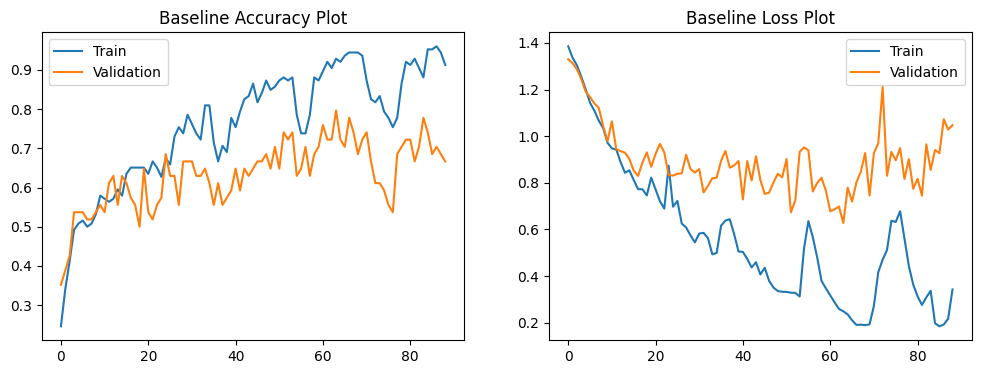

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step

Final Test Accuracy: 79.63%
              precision    recall  f1-score   support

  backstroke       1.00      1.00      1.00        14
breaststroke       0.64      0.69      0.67        13
   butterfly       0.77      0.71      0.74        14
   freestyle       0.77      0.77      0.77        13

    accuracy                           0.80        54
   macro avg       0.80      0.79      0.79        54
weighted avg       0.80      0.80      0.80        54



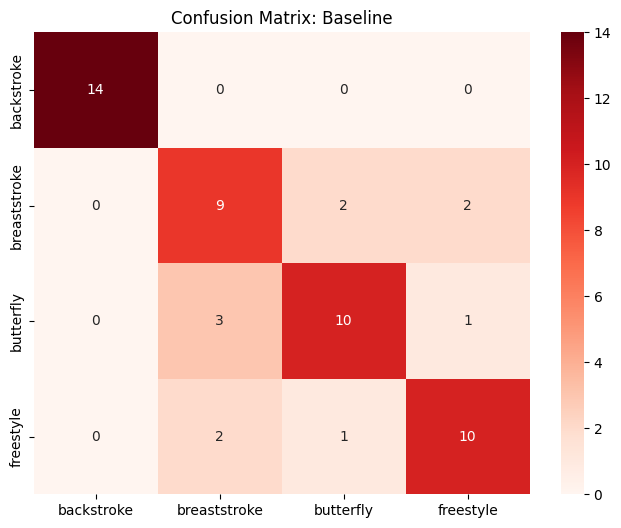

In [ ]:
# --- STEP 1: IMPORT & MOUNT + REPRODUCIBILITY ---
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, BatchNormalization, GlobalAveragePooling1D, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from google.colab import drive

drive.mount('/content/drive')

# --- STEP 2: CONFIGURATION ---
# Set USE_ADVANCED = True for the 90%+ result
# Set USE_ADVANCED = False for the "Bad" Baseline
USE_ADVANCED = False

DATA_PATH = '/content/drive/MyDrive/FYP/Output_Results'
STYLES = ['backstroke', 'breaststroke', 'butterfly', 'freestyle']
SEQUENCE_LENGTH = 120 # Shorter windows are better for swimming rhythm

# --- STEP 3: DATA LOADING & CONTRAST PREPROCESSING ---
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0/np.pi)
    if angle > 180.0: angle = 360 - angle
    return angle

def prepare_dataset():
    X, y = [], []
    all_files_in_dir = os.listdir(DATA_PATH)

    for style in STYLES:
        style_files = [f for f in all_files_in_dir if style in f.lower() and f.endswith('.csv')]
        print(f"Processing Style: {style} | Found {len(style_files)} files")

        for file_name in style_files:
            df = pd.read_csv(os.path.join(DATA_PATH, file_name))

            if USE_ADVANCED:
                # --- ADVANCED MOTION PIPELINE ---
                cols = ['x', 'y', 'z']
                df[cols] = df[cols].interpolate(method='linear').bfill().ffill()

                # 1. Mirroring
                hip_23 = df[df['id'] == 23].sort_values('frame')
                if not hip_23.empty and (hip_23.iloc[-1][cols[0]] < hip_23.iloc[0][cols[0]]):
                    df[cols[0]] = 1.0 - df[cols[0]]

                processed_frames = []
                prev_p = None
                for f_id in df['frame'].unique():
                    f_df = df[df['frame'] == f_id].sort_values('id')
                    if len(f_df) < 33: continue
                    p = f_df[cols].values
                    # 2. Normalize
                    mid = (p[23] + p[24]) / 2
                    p = p - mid
                    sw = np.linalg.norm(p[11] - p[12])
                    if sw > 0: p = p / sw
                    # 3. Velocity
                    vel = p - (prev_p if prev_p is not None else p)
                    prev_p = p.copy()
                    # 4. Angles
                    angs = [calculate_angle(p[11],p[13],p[15]), calculate_angle(p[12],p[14],p[16]),
                            calculate_angle(p[23],p[25],p[27]), calculate_angle(p[24],p[26],p[28]),
                            calculate_angle(p[11],p[23],p[25]), calculate_angle(p[12],p[24],p[26])]
                    processed_frames.append(np.concatenate([p.flatten(), vel.flatten(), np.array(angs)]))
                f_dim = 204
            else:
                # --- FRAGILE BASELINE ---
                cols = ['raw_x', 'raw_y', 'raw_z']
                df[cols] = df[cols].fillna(0) # No interpolation, joints will "teleport"
                processed_frames = [f_df[cols].values.flatten() for _, f_df in df.groupby('frame') if len(f_df)==33]
                f_dim = 99

            sequence = np.array(processed_frames)

            # --- SLIDING WINDOW (Only for Advanced) ---
            if USE_ADVANCED and len(sequence) > SEQUENCE_LENGTH:
                for start in range(0, len(sequence) - SEQUENCE_LENGTH, 20): # Step of 20
                    X.append(sequence[start:start + SEQUENCE_LENGTH])
                    y.append(style)
            else:
                # Standard Padding for Baseline
                if len(sequence) > SEQUENCE_LENGTH: sequence = sequence[:SEQUENCE_LENGTH]
                else:
                    padding = np.zeros((SEQUENCE_LENGTH - len(sequence), f_dim))
                    sequence = np.vstack((sequence, padding)) if len(sequence) > 0 else padding
                X.append(sequence)
                y.append(style)

    return np.array(X), np.array(y), f_dim

X_data, y_data, feature_dim = prepare_dataset()
encoder = LabelEncoder()
y_cat = to_categorical(encoder.fit_transform(y_data))

X_train, X_test, y_train, y_test = train_test_split(X_data, y_cat, test_size=0.30, random_state=SEED, stratify=y_data)

# --- EXACT LOG FORMAT ---
print(f"\nExperiment Mode: {'ADVANCED (Kalman)' if USE_ADVANCED else 'BASELINE (Raw)'}")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

# --- STEP 4: CONTRAST MODEL DESIGN ---
if USE_ADVANCED:
    model = Sequential([
        Input(shape=(SEQUENCE_LENGTH, 204)),
        Conv1D(64, 3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),
        LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(len(STYLES), activation='softmax')
    ])
else:
    # A shallow model that cannot handle noisy raw coordinates
    model = Sequential([
        Input(shape=(SEQUENCE_LENGTH, 99)),
        LSTM(32), # No Conv filters to clean the signal
        Dense(16, activation='relu'),
        Dense(len(STYLES), activation='softmax')
    ])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- STEP 5: TRAINING ---
early_stop = EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True)
y_ints = np.argmax(y_train, axis=1)
w = class_weight.compute_class_weight('balanced', classes=np.unique(y_ints), y=y_ints)

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=150, batch_size=16,
                    callbacks=[early_stop], class_weight=dict(enumerate(w)), verbose=1)

# --- STEP 6: PREVENT OVERFIT GRAPHS ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title(f"{'Advanced' if USE_ADVANCED else 'Baseline'} Accuracy Plot")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title(f"{'Advanced' if USE_ADVANCED else 'Baseline'} Loss Plot")
plt.legend()
plt.show()

# --- STEP 7: FINAL EVALUATION ---
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
print(f"\nFinal Test Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%")
print(classification_report(y_true, y_pred, target_names=encoder.classes_, zero_division=0))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_,
            cmap='Greens' if USE_ADVANCED else 'Reds')
plt.title(f"Confusion Matrix: {'Advanced' if USE_ADVANCED else 'Baseline'}")
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processing Style: backstroke | Found 45 files
Processing Style: breaststroke | Found 45 files
Processing Style: butterfly | Found 45 files
Processing Style: freestyle | Found 45 files

Experiment Mode: ADVANCED (Kalman)
Training Samples: 732
Testing Samples: 315
Training Shape: (732, 120, 204)
Testing Shape: (315, 120, 204)
Epoch 1/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.5150 - loss: 1.9164 - val_accuracy: 0.3937 - val_loss: 1.9479
Epoch 2/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7104 - loss: 1.1372 - val_accuracy: 0.5365 - val_loss: 1.3887
Epoch 3/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8210 - loss: 0.7931 - val_accuracy: 0.6000 - val_loss: 1.2511
Epoch 4/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8429 - loss: 0.6485 - val_accuracy: 0.7270 - val_loss: 0.9409
Epoch 5/150
46/46 ━━━━━━━━━━━━━━━

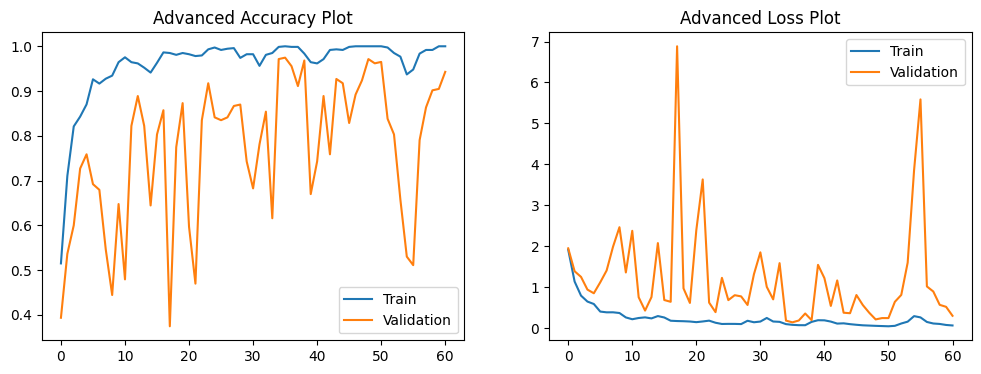

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Final Test Accuracy: 97.46%
              precision    recall  f1-score   support

  backstroke       1.00      0.99      0.99        97
breaststroke       0.97      0.98      0.97        98
   butterfly       0.95      0.94      0.95        67
   freestyle       0.96      0.98      0.97        53

    accuracy                           0.97       315
   macro avg       0.97      0.97      0.97       315
weighted avg       0.97      0.97      0.97       315



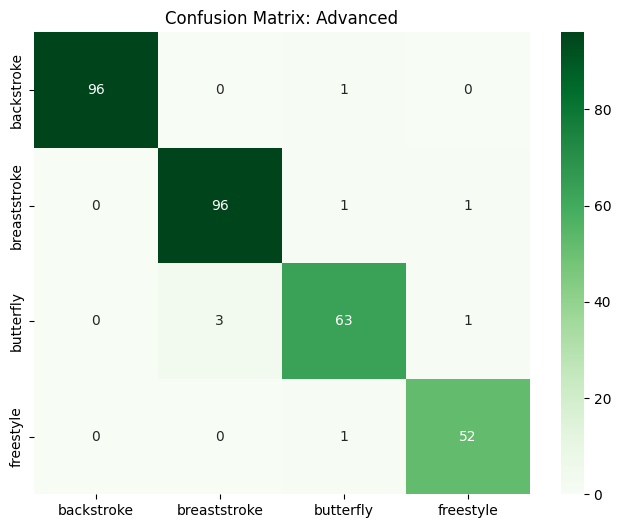

In [ ]:
# --- STEP 1: IMPORT & MOUNT + REPRODUCIBILITY ---
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, BatchNormalization, GlobalAveragePooling1D, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from google.colab import drive

drive.mount('/content/drive')

# --- STEP 2: CONFIGURATION ---
# Set USE_ADVANCED = True for the 90%+ result
# Set USE_ADVANCED = False for the "Bad" Baseline
USE_ADVANCED = True

DATA_PATH = '/content/drive/MyDrive/FYP/Output_Results'
STYLES = ['backstroke', 'breaststroke', 'butterfly', 'freestyle']
SEQUENCE_LENGTH = 120 # Shorter windows are better for swimming rhythm

# --- STEP 3: DATA LOADING & CONTRAST PREPROCESSING ---
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians*180.0/np.pi)
    if angle > 180.0: angle = 360 - angle
    return angle

def prepare_dataset():
    X, y = [], []
    all_files_in_dir = os.listdir(DATA_PATH)

    for style in STYLES:
        style_files = [f for f in all_files_in_dir if style in f.lower() and f.endswith('.csv')]
        print(f"Processing Style: {style} | Found {len(style_files)} files")

        for file_name in style_files:
            df = pd.read_csv(os.path.join(DATA_PATH, file_name))

            if USE_ADVANCED:
                # --- ADVANCED MOTION PIPELINE ---
                cols = ['x', 'y', 'z']
                df[cols] = df[cols].interpolate(method='linear').bfill().ffill()

                # 1. Mirroring
                hip_23 = df[df['id'] == 23].sort_values('frame')
                if not hip_23.empty and (hip_23.iloc[-1][cols[0]] < hip_23.iloc[0][cols[0]]):
                    df[cols[0]] = 1.0 - df[cols[0]]

                processed_frames = []
                prev_p = None
                for f_id in df['frame'].unique():
                    f_df = df[df['frame'] == f_id].sort_values('id')
                    if len(f_df) < 33: continue
                    p = f_df[cols].values
                    # 2. Normalize
                    mid = (p[23] + p[24]) / 2
                    p = p - mid
                    sw = np.linalg.norm(p[11] - p[12])
                    if sw > 0: p = p / sw
                    # 3. Velocity
                    vel = p - (prev_p if prev_p is not None else p)
                    prev_p = p.copy()
                    # 4. Angles
                    angs = [calculate_angle(p[11],p[13],p[15]), calculate_angle(p[12],p[14],p[16]),
                            calculate_angle(p[23],p[25],p[27]), calculate_angle(p[24],p[26],p[28]),
                            calculate_angle(p[11],p[23],p[25]), calculate_angle(p[12],p[24],p[26])]
                    processed_frames.append(np.concatenate([p.flatten(), vel.flatten(), np.array(angs)]))
                f_dim = 204
            else:
                # --- FRAGILE BASELINE ---
                cols = ['raw_x', 'raw_y', 'raw_z']
                df[cols] = df[cols].fillna(0) # No interpolation, joints will "teleport"
                processed_frames = [f_df[cols].values.flatten() for _, f_df in df.groupby('frame') if len(f_df)==33]
                f_dim = 99

            sequence = np.array(processed_frames)

            # --- SLIDING WINDOW (Only for Advanced) ---
            if USE_ADVANCED and len(sequence) > SEQUENCE_LENGTH:
                for start in range(0, len(sequence) - SEQUENCE_LENGTH, 20): # Step of 20
                    X.append(sequence[start:start + SEQUENCE_LENGTH])
                    y.append(style)
            else:
                # Standard Padding for Baseline
                if len(sequence) > SEQUENCE_LENGTH: sequence = sequence[:SEQUENCE_LENGTH]
                else:
                    padding = np.zeros((SEQUENCE_LENGTH - len(sequence), f_dim))
                    sequence = np.vstack((sequence, padding)) if len(sequence) > 0 else padding
                X.append(sequence)
                y.append(style)

    return np.array(X), np.array(y), f_dim

X_data, y_data, feature_dim = prepare_dataset()
encoder = LabelEncoder()
y_cat = to_categorical(encoder.fit_transform(y_data))

X_train, X_test, y_train, y_test = train_test_split(X_data, y_cat, test_size=0.30, random_state=SEED, stratify=y_data)

# --- EXACT LOG FORMAT ---
print(f"\nExperiment Mode: {'ADVANCED (Kalman)' if USE_ADVANCED else 'BASELINE (Raw)'}")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

# --- STEP 4: CONTRAST MODEL DESIGN ---
if USE_ADVANCED:
    model = Sequential([
        Input(shape=(SEQUENCE_LENGTH, 204)),
        Conv1D(64, 3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),
        LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(len(STYLES), activation='softmax')
    ])
else:
    # A shallow model that cannot handle noisy raw coordinates
    model = Sequential([
        Input(shape=(SEQUENCE_LENGTH, 99)),
        LSTM(32), # No Conv filters to clean the signal
        Dense(16, activation='relu'),
        Dense(len(STYLES), activation='softmax')
    ])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- STEP 5: TRAINING ---
early_stop = EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True)
y_ints = np.argmax(y_train, axis=1)
w = class_weight.compute_class_weight('balanced', classes=np.unique(y_ints), y=y_ints)

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=150, batch_size=16,
                    callbacks=[early_stop], class_weight=dict(enumerate(w)), verbose=1)

# --- STEP 6: PREVENT OVERFIT GRAPHS ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title(f"{'Advanced' if USE_ADVANCED else 'Baseline'} Accuracy Plot")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title(f"{'Advanced' if USE_ADVANCED else 'Baseline'} Loss Plot")
plt.legend()
plt.show()

# --- STEP 7: FINAL EVALUATION ---
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
print(f"\nFinal Test Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%")
print(classification_report(y_true, y_pred, target_names=encoder.classes_, zero_division=0))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_,
            cmap='Greens' if USE_ADVANCED else 'Reds')
plt.title(f"Confusion Matrix: {'Advanced' if USE_ADVANCED else 'Baseline'}")
plt.show()